# INTRODUCTION AND OUTLINE #

## HYPOTHESIS ##

The current corner betting markets are inefficient. When assessing a teams corner attack and defence ratings the market only accounts for the raw number of corners won and conceded. However over short time periods teams corner performances can be skewed by game state affects and the quality of the teams they are facing. 

This project outlines how to gain an edge betting on corner markets by looking at the context in which corners are won and conceded. The analysis shows how we can correct for these biases and create better optimised team corner ratings to be used in predictive models. This creates a more nuanced picture of a teams corner performances that we can use to make better corner predictions in individual matches.

This project is split up into the following sections

PROCESSING
1. Identifying game state at each match event
2. Calculating the minutes spent in each game state at the start and end of each match
3. Calculating the minutes spent in intermediate game states
4. Calculating the total number of minutes each team spends in each game state
5. Identifying the number of corners won in each game state
6. Identifying corners that are repeaters
7. Data validation

ANALYSIS
1. The extent to which game state affects corner rates
2. How game state can affect corner output in the short term
3. How repeaters affect corner rates
4. How match supremacy affects corner rates
5. Extract coefficients to create adjusted corner values
6. Create adjusted corner values that correct for these biases
7. Case study into how corner values can be adjusted to create more robust corner ratings
8. Limitations and Further Improvements


### PACKAGE IMPORTS ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### DATA IMPORT ###

In [2]:
df = pd.read_csv('data\corner_gamestate.csv')

In [3]:
df_sample = df[df['matchid'] == '2025-02-12-Everton-Liverpool']

df_sample_events = df_sample[['Home', 'Away', 'Team', 'Minute', 'Event']]

In [4]:
df_sample_events

,Home,Away,Team,Minute,Event
906,Everton,Liverpool,Everton,5,Corner
907,Everton,Liverpool,Everton,11,Goal
908,Everton,Liverpool,Liverpool,16,Goal
909,Everton,Liverpool,Liverpool,27,Yellow Card
910,Everton,Liverpool,Everton,35,Yellow Card
911,Everton,Liverpool,Everton,37,Yellow Card
912,Everton,Liverpool,Liverpool,38,Corner
913,Everton,Liverpool,Liverpool,47,Yellow Card
914,Everton,Liverpool,Everton,48,Yellow Card
915,Everton,Liverpool,Liverpool,52,Corner


The data in this data frame is scraped from totalcorner.com. It has has already had some pre processing applied to alter data types and formatting issues, and to add columns related to expected match goals and supremacy based on betting lines.

The data contains a row for each event in the match. In order to calculate how long each team spent in each gamestate we must calculate the current score and gamestate after each goal and then calculate how long each game state lasted for in each match. We can also use this to work out the game state at each corner event later in the analysis.

## PROCESSING ##

#### IDENTIFYING GAME STATE AT EACH MATCH EVENT ####

Here we are summing the cumulative goals for each team, establishing the current game state for each event, then identifying minutes where the game state changed.

In [5]:
# Counts goals to find what game state events happened in
df['home_goals'] = ((df['Event'] == 'Goal') & (df['Team'] == df['Home'])).groupby(df['matchid']).cumsum()
df['away_goals'] = ((df['Event'] == 'Goal') & (df['Team'] == df['Away'])).groupby(df['matchid']).cumsum()

# Defines current gamestate at each event based on the current score
def gamestate(df):
    if df['home_goals'] > df['away_goals']:
        return 1
    if df['home_goals'] < df['away_goals']:
        return 2
    return 0

df['gamestate'] = df.apply(gamestate, axis=1)

# Minute and direction that game state changed
df['gamestate_change'] = df.groupby('matchid')['gamestate'].diff().fillna(0)

In [9]:
df_sample_gs = df[df['matchid'] == '2025-02-12-Everton-Liverpool']

df_sample_gs = df_sample_gs[['Home', 'Away', 'Team', 'Minute', 'Event', 'home_goals', 'away_goals', 'gamestate', 'gamestate_change']]

In [10]:
df_sample_gs

,Home,Away,Team,Minute,Event,home_goals,away_goals,gamestate,gamestate_change
906,Everton,Liverpool,Everton,5,Corner,0,0,0,0.0
907,Everton,Liverpool,Everton,11,Goal,1,0,1,1.0
908,Everton,Liverpool,Liverpool,16,Goal,1,1,0,-1.0
909,Everton,Liverpool,Liverpool,27,Yellow Card,1,1,0,0.0
910,Everton,Liverpool,Everton,35,Yellow Card,1,1,0,0.0
911,Everton,Liverpool,Everton,37,Yellow Card,1,1,0,0.0
912,Everton,Liverpool,Liverpool,38,Corner,1,1,0,0.0
913,Everton,Liverpool,Liverpool,47,Yellow Card,1,1,0,0.0
914,Everton,Liverpool,Everton,48,Yellow Card,1,1,0,0.0
915,Everton,Liverpool,Liverpool,52,Corner,1,1,0,0.0


The data frame now contains columns that show the game state at each event, identifies minutes where the game state changed and the direction of this change.

#### CALCULATING THE MINUTES SPENT IN GAME STATE AT THE BEGINNING AND END OF EACH MATCH ####

In this section we identify the amount of minutes spent in the initial drawing phase of the match and the amount of minutes spent in the final game state of the match.

In [11]:
# Initial drawing state
df['drawingmins'] = np.where(
    (df.groupby(['matchid', 'Event']).cumcount() == 0) & (df['Event'] == 'Goal'),
    df['Minute'],
    0
)

# Minutes where there was a change in game state - also handles cases where goal is first event
df['gs_change_min'] = np.where(
    df['gamestate_change'].isin([1, 2, -1, -2]),
    df['Minute'],
    df['drawingmins']
)

# Total mins in match - assumed to be time of last match event or 97 (whichever is bigger)
df['matchmins'] = np.where(df.groupby('matchid')['Minute'].transform('max') > 97,
                           df.groupby('matchid')['Minute'].transform('max'), 97)

# Time spent in final game state at the end of the match
df['final_gs_mins'] = df['matchmins'] - df.groupby('matchid')['gs_change_min'].transform('max')

# Mask for last row in each match
mask_last_row = df.groupby('matchid').cumcount(ascending=False) == 0

# Final game state minutes for home, away, and drawing
df['homeleadmins'] = np.where((df['gamestate'] == 1) & mask_last_row, df['final_gs_mins'], 0)
df['awayleadmins'] = np.where((df['gamestate'] == 2) & mask_last_row, df['final_gs_mins'], 0)
df['drawingmins'] = np.where((df['gamestate'] == 0) & mask_last_row, df['final_gs_mins'], df['drawingmins'])

#### CALCULATING THE MINUTES SPENT IN INTERMEDIATE GAME STATES ####

In this section we establish how long each intermediary game state lasted and add these minutes to to our totals for each match

In [12]:
# Calculates the difference between non 0 values of 'gs_change_min' to find mins in each game state
df['gs_mins'] = df.groupby('matchid')['gs_change_min'].transform(
    lambda x: x.where(x != 0).ffill().fillna(0).diff().fillna(0)
)

# Tidies up instances where match game state changes twice around HT 
df['gs_mins'] = np.where(df['gs_mins'] < 0 , 1 , df['gs_mins'])

# Calculates intermediate minutes spent in each gamestate
df['homeleadmins'] = np.where(df['gamestate_change'] == -1, df['gs_mins'], df['homeleadmins'])
df['awayleadmins'] = np.where(df['gamestate_change'] == -2, df['gs_mins'], df['awayleadmins'])
df['drawingmins'] = np.where(df['gamestate_change'].isin([1, 2]), df['gs_mins'], df['drawingmins'])

#### TOTAL GAME STATE MINS FROM MATCH AND TEAM PERSPECTIVE ####

Finally we sum these to get match totals and create new columns for individual team game state minutes

In [13]:
# Total game state minutes for each match
df['homeleadmins'] = df.groupby('matchid')['homeleadmins'].transform('sum')
df['awayleadmins'] = df.groupby('matchid')['awayleadmins'].transform('sum')
df['drawingmins'] = df.groupby('matchid')['drawingmins'].transform('sum')

# Creates team leading, losing, drawing columns
df['teamleadingmins'] = np.where(df['Team'] == df['Home'], df['homeleadmins'],
                                 np.where(df['Team'] == df['Away'], df['awayleadmins'], 0))

df['teamlosingmins'] = np.where(df['Team'] == df['Home'], df['awayleadmins'],
                                 np.where(df['Team'] == df['Away'], df['homeleadmins'], 0))

df['teamdrawingmins'] = df['drawingmins']

# Removes matches with corrupted data
df['matchminscheck'] = df['matchmins'] - (df['homeleadmins'] + df['awayleadmins'] + df['drawingmins'])

df = df[df['matchminscheck'] == 0].copy()

In [18]:
df_match = df.groupby('matchid').first().reset_index()

df_match = df_match.sort_values(['League', 'Date'], ascending=False)

df_match_sample = df_match.sample(10)

df_match_sample = df_match_sample[['Date', 'League', 'Home', 'Away', 'homeleadmins', 'awayleadmins', 'drawingmins']]

In [19]:
df_match_sample

,Date,League,Home,Away,homeleadmins,awayleadmins,drawingmins
2734,2015-10-03,Germany Bundesliga I,Borussia M'gladbach,Wolfsburg,22.0,0.0,75.0
18397,2022-04-04,Italy Serie A,Verona,Genoa,92.0,0.0,5.0
14699,2020-11-22,England Premier League,Sheff Utd,West Ham,0.0,41.0,56.0
22426,2024-01-05,Portugal Primeira Liga,Boavista,FC Porto,0.0,5.0,96.0
19485,2022-10-15,Germany Bundesliga I,RB Leipzig,Hertha Berlin,72.0,0.0,25.0
9495,2018-05-19,Italy Serie A,Juventus,Verona,48.0,0.0,49.0
20126,2023-01-29,Spain La Liga,Osasuna,Atletico Madrid,0.0,23.0,74.0
21898,2023-10-28,Italy Serie A,Sassuolo,Bologna,0.0,41.0,56.0
11889,2019-05-18,Spain La Liga,Levante,Atletico Madrid,73.0,0.0,24.0
17345,2021-11-20,England Premier League,Wolverhampton,West Ham,39.0,0.0,58.0


We now have a columns that show the amount of time each team spent in each game state in each match to use in our analysis

#### FINDING THE NUMBER OF CORNERS WON IN EACH GAMESTATE ####

Next we can look at how many corners were won and lost by each team in each gamestate

In [20]:
# Find number of corners in each gamestate
df['homeleadingcorner'] = np.where((df['gamestate'] == 1) & (df['Event'] == 'Corner') & (df['Team'] == df['Home']), 1, 0)
df['homelosingcorner'] = np.where((df['gamestate'] == 2) & (df['Event'] == 'Corner') & (df['Team'] == df['Home']), 1, 0)
df['homedrawingcorner'] = np.where((df['gamestate'] == 0) & (df['Event'] == 'Corner') & (df['Team'] == df['Home']), 1, 0)
df['awayleadingcorner'] = np.where((df['gamestate'] == 2) & (df['Event'] == 'Corner') & (df['Team'] == df['Away']), 1, 0)
df['awaylosingcorner'] = np.where((df['gamestate'] == 1) & (df['Event'] == 'Corner') & (df['Team'] == df['Away']), 1, 0)
df['awaydrawingcorner'] = np.where((df['gamestate'] == 0) & (df['Event'] == 'Corner') & (df['Team'] == df['Away']), 1, 0)

# Finds sum of corners in each of these game states for each match
df['home_leading_corners'] = df.groupby('matchid')['homeleadingcorner'].transform('sum')
df['home_losing_corners'] = df.groupby('matchid')['homelosingcorner'].transform('sum')
df['home_drawing_corners'] = df.groupby('matchid')['homedrawingcorner'].transform('sum')
df['away_leading_corners'] = df.groupby('matchid')['awayleadingcorner'].transform('sum')
df['away_losing_corners'] = df.groupby('matchid')['awaylosingcorner'].transform('sum')
df['away_drawing_corners'] = df.groupby('matchid')['awaydrawingcorner'].transform('sum')


df['team_leading_corners'] = np.where(df['Team'] == df['Home'], df['home_leading_corners'],
                                 np.where(df['Team'] == df['Away'], df['away_leading_corners'], 0))

df['team_losing_corners'] = np.where(df['Team'] == df['Home'], df['home_losing_corners'],
                                 np.where(df['Team'] == df['Away'], df['away_losing_corners'], 0))

df['team_drawing_corners'] = np.where(df['Team'] == df['Home'], df['home_drawing_corners'],
                                 np.where(df['Team'] == df['Away'], df['away_drawing_corners'], 0))

In [23]:
df_team_match = df.groupby('teammatchid').first().reset_index()

df_team_match = df_team_match.sort_values(['League', 'Date', 'matchid'], ascending=False)

df_team_match = df_team_match.sample(10)

df_team_match = df_team_match[['Date', 'League', 'Home', 'Away', 'team_leading_corners', 'team_losing_corners', 'team_drawing_corners']]

In [24]:
df_team_match

,Date,League,Home,Away,team_leading_corners,team_losing_corners,team_drawing_corners
43895,2023-11-05,Netherlands Eredivisie,NEC,FC Volendam,3,1,4
12197,2017-02-05,Spain La Liga,Sevilla,Villarreal,0,0,9
26230,2020-01-11,England Premier League,Chelsea,Burnley,4,0,6
46481,2024-04-19,Portugal Primeira Liga,Rio Ave,FC Arouca,1,0,3
6424,2015-12-05,France Ligue 1,SC Bastia,Monaco,0,0,2
6718,2015-12-20,Italy Serie A,Roma,Genoa,0,6,2
48923,2024-12-07,Portugal Primeira Liga,Famalicao,FC Porto,0,0,5
1752,2014-12-14,Italy Serie A,Parma,Cagliari,0,0,3
41097,2023-03-18,Germany Bundesliga I,TSG Hoffenheim,Hertha Berlin,4,0,4
44882,2024-01-14,Portugal Primeira Liga,FC Porto,Braga,0,5,0


This data frame now contains columns for how many corners were won or conceded in each game state. We can use this to create game state adjusted corner ratings later in the analysis.

#### IDENTIFIES REPEATERS ####

Repeaters are corners that immediately follow other corners. Repeaters are defined here as any corner for the same team that is in the same minute or the minute after the previous corner, and in the same half.

In [25]:
df['Corner'] = np.where(df['Event'] == 'Corner', 1, 0)

df['Repeater'] = np.where(
    (df['Event'] == 'Corner') &
    (df['Corner'].shift(1, fill_value=0) == 1) &
    (df['half'] == df['half'].shift(1, fill_value=0)) &
    (df['teammatchid'] == df['teammatchid'].shift(1, fill_value=df['teammatchid'].iloc[0])) &
    ((df['Minute'] - df.groupby('matchid')['Minute'].shift(1)).fillna(df['Minute']) < 2),
    1, 0
)

#### DATA VALIDATION ####
Here we remove any matches with inconsistent corner counts (corrupted data) and create a smaller data frame for our analysis

In [26]:
df['total_corners_sum'] = df[['home_leading_corners', 'home_losing_corners', 'home_drawing_corners', 
'away_leading_corners', 'away_losing_corners','away_drawing_corners']].sum(axis = 1)

df['total_corners_check'] = df['total_corners_sum'] - df['total_corners']

df = df[df['total_corners_check'] == 0]

df_gs = df[['Date', 'League','Home', 'Away', 'Team', 'Minute', 'Home.Corners', 'Away.Corners', 'total_corners', 'matchid', 'teammatchid', 'matchsup', 'teamsup',
            'matchgoals', 'hcaplevel', 'goallevel', 'gamestate', 'Event', 'Corner', 'Repeater', 
            'homeleadmins', 'awayleadmins', 'drawingmins', 'teamleadingmins', 'teamlosingmins', 'teamdrawingmins',
            'team_leading_corners', 'team_losing_corners', 'team_drawing_corners']].copy()

## ANALYSIS ##

#### GAME STATE AFFECTS CORNER RATES ####

Teams get more corners when they are drawing compared to when they are winning, and they get more corners when they are losing compared to when they are drawing. This is because when a team is losing or drawing there is more incentive for them to attack so they generate more shots, crosses and other attacking actions that lead to corners.


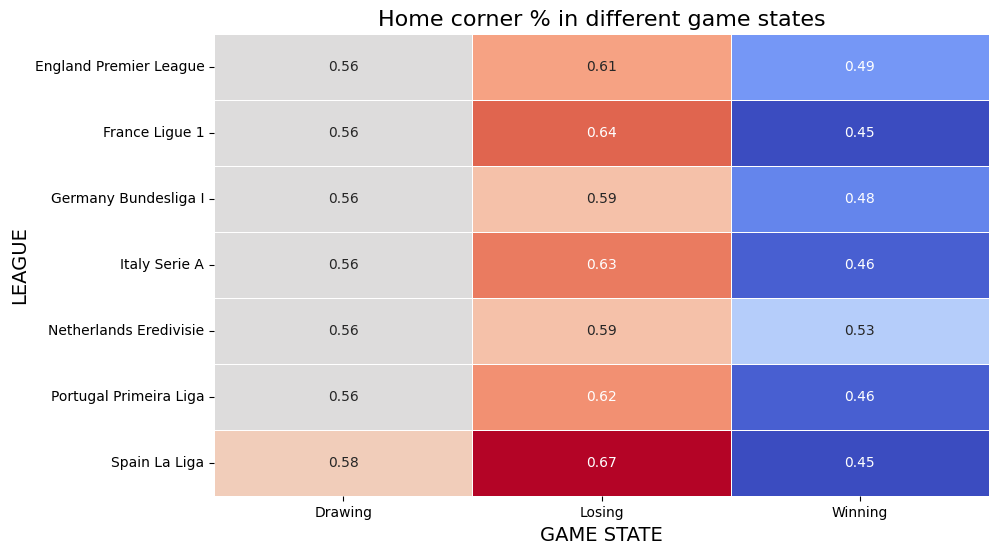

In [27]:
# Identifies home and away corners in each match
df_gs['homecorners'] = np.where((df_gs['Event'] == 'Corner') & (df_gs['Team'] == df['Home']), 1, 0)
df_gs['awaycorners'] = np.where((df_gs['Event'] == 'Corner') & (df_gs['Team'] == df['Away']), 1, 0)

# Creates table that sums the number of corner in each game state and league
df_gs_league = df_gs.groupby(['gamestate', 'League']).agg(
    home_corners=('homecorners', 'sum'),
    away_corners=('awaycorners', 'sum')
).reset_index()

# Calculates the percentage of corners in each game state and league
df_gs_league['home_pc'] = df_gs_league['home_corners'] / (df_gs_league['home_corners'] + df_gs_league['away_corners'])
df_gs_league['gamestate'] = df_gs_league['gamestate'].replace({
    0: 'Drawing',
    1: 'Winning',
    2: 'Losing'
})

df_gs_league = df_gs_league.drop(columns = (['home_corners', 'away_corners']))
df_gs_league = df_gs_league.pivot(index="League", columns="gamestate")
df_gs_league.columns = df_gs_league.columns.droplevel(0)
df_gs_league = df_gs_league.round(2)

# Plots heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_gs_league[["Drawing", "Losing", "Winning"]],
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    cbar=False  # This removes the color bar
    #fmt=".2f"
)
plt.title("Home corner % in different game states", fontsize=16)
plt.ylabel("LEAGUE", fontsize=14)
plt.xlabel("GAME STATE", fontsize=14)
plt.show()


The chart shows the effect that game state has on corner generation. The difference in the percentage of corners the home team gets can be as much as 21% (Spain Primera) depending on if they are winning or losing.

It also shows interesting differences between leagues. This is likely a result of differing tactical cultures and the prevalence of away fans in some countries.

It means we have to take a league specific approach when adjusting for game state effects.


#### GAME STATE CAN AFFECT CORNER OUTPUT IN THE SHORT TERM ####

The previous chart showed the effect that game state can have on corners. However, over short time frames, teams can spend a disproportionate amount of time in game states we would not “expect” them to be in based on the underlying strength of the team. These short term fluctuations in game state minutes can distort a teams true corner attack and defence ratings.

This section merges the data frame with a look up table of expected game state mins based on betting lines.

In [28]:
# Creates dataframe with unique row for each team and match
df_gs_team = df_gs.groupby('teammatchid').first().reset_index()

# Filters for a specific league and time frame
df_gs_team_prem = df_gs_team[df_gs_team['League'] == 'England Premier League'].copy()
df_gs_team_prem['Date'] = pd.to_datetime(df_gs_team_prem['Date'])
df_gs_team_prem = df_gs_team_prem[(df_gs_team_prem['Date'] > '2023-07-01') & (df_gs_team_prem['Date'] < '2023-11-01')]

# Merges with mins file to get expected leading mins based on goals and supremacy
mins_conv = pd.read_csv('data\mins_conv.csv')
df_gs_team_prem['hcaplevel'] = 0 - df_gs_team_prem['hcaplevel']
df_gs_team_prem = pd.merge(df_gs_team_prem, mins_conv, on=["hcaplevel", "goallevel"], how="left")

#### TEAM  MINS ANALYSIS ####
This section creates a table that show the number of minutes each team should have spent in each game state over this period based on pre match goals and asian handicap lines. It also makes a table that shows the actual number of minutes each team spent in each game state over the same period for comparison.

In [29]:
# Expected mins analysis
df_mins_exp = df_gs_team_prem.copy()

# Assigns expected team leading mins for each match
df_mins_exp['teamleadmins_exp'] = np.where(df_mins_exp['Team'] == df_mins_exp['Home'], df_mins_exp['home_leading'],
                                 np.where(df_mins_exp['Team'] == df_mins_exp['Away'], df_mins_exp['away_leading'], 0))

df_mins_exp['teamlosing_exp'] = np.where(df_mins_exp['Team'] == df_mins_exp['Home'], df_mins_exp['away_leading'],
                                 np.where(df_mins_exp['Team'] == df_mins_exp['Away'], df_mins_exp['home_leading'], 0))

df_mins_exp['teamdrawing_exp'] = df_mins_exp['drawing_mins']

# Aggregates expected game state mins for each team
df_mins_exp = df_mins_exp.groupby('Team').agg(
    leading_mins=('teamleadmins_exp', 'sum'),
    drawing_mins=('teamdrawing_exp', 'sum'),
    losing_mins=('teamlosing_exp', 'sum')
).reset_index()

# Works out the percentage of exepected mins in each gametstate for each team
df_mins_exp['Leading'] = df_mins_exp['leading_mins'] / df_mins_exp[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)
df_mins_exp['Drawing'] = df_mins_exp['drawing_mins'] / df_mins_exp[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)
df_mins_exp['Losing'] = df_mins_exp['losing_mins'] / df_mins_exp[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)

df_mins_exp = df_mins_exp.sort_values(by='Leading', ascending=True)

# Actual mins analysis
df_mins_act = df_gs_team_prem.copy()

# Aggregates actual game state mins for each team
df_mins_act = df_mins_act.groupby('Team').agg(
    leading_mins=('teamleadingmins', 'sum'),
    drawing_mins=('teamdrawingmins', 'sum'),
    losing_mins=('teamlosingmins', 'sum')
).reset_index()

# Works out the percentage of actual mins in each gamestate for each team
df_mins_act['Leading'] = df_mins_act['leading_mins'] / df_mins_act[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)
df_mins_act['Drawing'] = df_mins_act['drawing_mins'] / df_mins_act[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)
df_mins_act['Losing'] = df_mins_act['losing_mins'] / df_mins_act[['leading_mins', 'drawing_mins', 'losing_mins']].sum(axis=1)

#### TEAM GAMESTATE MINS CHART ####
This section creates a chart to illustrate how teams can spend a disproportionate amount of time in different game states realtive to their underlying strength.

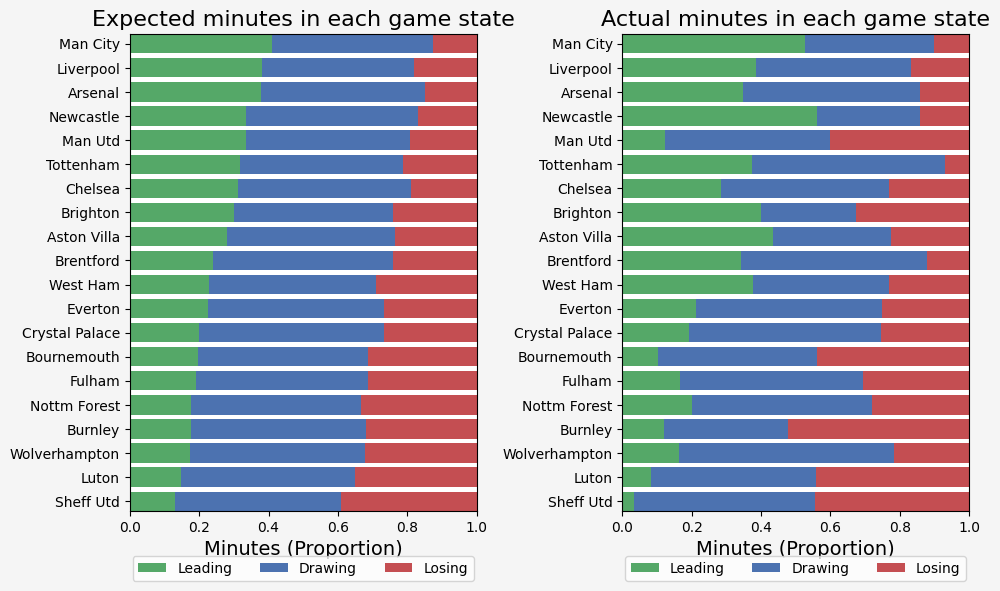

In [31]:
# Consistent team order across the two charts
df_mins_act['Team'] = pd.Categorical(df_mins_act['Team'], categories=df_mins_exp['Team'], ordered=True)
df_mins_act = df_mins_act.sort_values('Team')

# Creates figure with sub plots and set background colour
fig, (ax_exp, ax_act) = plt.subplots(1, 2, figsize=(10, 6))
fig.patch.set_facecolor('#F5F5F5')

# Bars for expected minutes
ax_exp.barh(df_mins_exp['Team'], df_mins_exp['Leading'], label='Leading', color='#55A868')
ax_exp.barh(df_mins_exp['Team'], df_mins_exp['Drawing'], left=df_mins_exp['Leading'], label='Drawing', color='#4C72B0')
ax_exp.barh(df_mins_exp['Team'], df_mins_exp['Losing'], left=df_mins_exp['Leading'] + df_mins_exp['Drawing'], label='Losing', color='#C44E52')

# Labels titles and formatting for expected minutes chart
ax_exp.set_xlabel('Minutes (Proportion)', fontsize=14)
ax_exp.set_title('Expected minutes in each game state', fontsize=16)
ax_exp.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)
ax_exp.margins(y=0)
ax_exp.margins(x=0)

# Bars for actual minutes
ax_act.barh(df_mins_act['Team'], df_mins_act['Leading'], label='Leading', color='#55A868')
ax_act.barh(df_mins_act['Team'], df_mins_act['Drawing'], left=df_mins_act['Leading'], label='Drawing', color='#4C72B0')
ax_act.barh(df_mins_act['Team'], df_mins_act['Losing'], left=df_mins_act['Leading'] + df_mins_act['Drawing'], label='Losing', color='#C44E52')

# Labels titles and formatting for actual minutes chart
ax_act.set_xlabel('Minutes (Proportion)', fontsize=14)
ax_act.set_title('Actual minutes in each game state', fontsize=16)
ax_act.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)
ax_act.margins(y=0)
ax_act.margins(x=0)

plt.tight_layout()

# Show plot
plt.show()

This data is from the first 9 matches of the 2023/24 Premier League season. The left chart shows how many minutes we would expect each team to be in each game state, based on pre match betting lines. The right chart show the minutes each team actually spent in each game state over the same set of fixtures. 

The previous chart showed the effect that game state can have on corners. This chart that over short time frames there can be big discrepancies in how many minutes each team spends in each game state compared to how many you could expect them to based on their underlying team strength. 

These short term fluctuations in game state minutes can distort a teams true corner attack and defence ratings, as their corner performances will be heavily influenced by the game state in these matches.

#### REPEATERS AFFECT CORNER RATES ####

Repeaters are corners that immediately follow other corners. Sometimes these can be 3, 4 or more in a row. Repeaters are not statistically independent from the corners that precede them. In the short term this can skew a teams corner statistics. 

In [36]:
# League repeater analysis
df_repeater_analysis = (
    df_gs
    .groupby('League')
    .agg(
        reps=('Repeater', 'sum'),
        corners=('Corner', 'sum')      
    )
    .reset_index()
)

df_repeater_analysis['rep_pc'] = df_repeater_analysis['reps'] / df_repeater_analysis['corners']

# Team repeater analysis
df_repeater_analysis_team = (
    df_gs
    .groupby(['League', 'Team'])
    .agg(
        matches=('teammatchid', 'nunique'),
        reps=('Repeater', 'sum'),
        corners=('Corner', 'sum')
    )
    .reset_index()
)

df_repeater_analysis_team['rep_pc'] = df_repeater_analysis_team['reps'] / df_repeater_analysis_team['corners']

df_repeater_analysis_team_sample = df_repeater_analysis_team[df_repeater_analysis_team['matches'] > 50].sample(10)

In [37]:
df_repeater_analysis

,League,reps,corners,rep_pc
0,England Premier League,6006,41555,0.144531
1,France Ligue 1,4604,35405,0.130038
2,Germany Bundesliga I,3927,30387,0.129233
3,Italy Serie A,5639,40299,0.139929
4,Netherlands Eredivisie,4309,31009,0.138960
5,Portugal Primeira Liga,4517,32001,0.141152
6,Spain La Liga,4823,37526,0.128524


In [38]:
df_repeater_analysis_team_sample

,League,Team,matches,reps,corners,rep_pc
142,Netherlands Eredivisie,FC Groningen,305,178,1381,0.128892
129,Italy Serie A,Torino,404,210,1884,0.111465
138,Netherlands Eredivisie,De Graafschap,64,42,314,0.133758
66,France Ligue 1,Toulouse,304,171,1394,0.122669
88,Germany Bundesliga I,Paderborn,60,37,312,0.118590
58,France Ligue 1,Nice,377,259,1785,0.145098
183,Portugal Primeira Liga,Portimonense,230,140,1058,0.132325
153,Netherlands Eredivisie,PEC Zwolle,304,192,1415,0.135689
110,Italy Serie A,Empoli,290,198,1385,0.142960
169,Portugal Primeira Liga,Desportivo Chaves,165,137,845,0.162130


Across a range of teams and leagues the rate of repeaters is consistently around 14%. Removing these from the totals completely will not bias any particular teams. Therefore in order to correct for the correlated nature of these types of corners we can exclude repeaters from our analysis altogether to gain a more accurate picture of a teams true corner strength.

#### GAME STATE - SUPREMACY ANALYSIS ####
Supremacy is defined as the expected number of goals a team is predicted to score in a match compared to their opponent, calculated here using pre match betting lines. Teams get more corners as the gap in supremacy between the teams increases, and this is true in all game states. This is because teams that score more goals also generate more crosses, shots and other attacking actions that lead to corners.

This section creates tables that show the amount of corners won per minute, broken down by the match supremacy and game state

In [39]:
# SUPREMACY ANALYSIS -  HOME TEAM

# Filter for La Liga matches, home team rows only and matches played behind closed doors
df_gs_laliga = df_gs[df_gs['League'] == 'Spain La Liga'].copy()
df_gs_team_laliga = df_gs_team[df_gs_team['League'] == 'Spain La Liga']
df_gs_team_laliga = df_gs_team_laliga[(df_gs_team_laliga['Date'] > '2021-07-01') | (df_gs_team_laliga['Date'] < '2020-04-01')]
df_gs_home = df_gs_team_laliga[df_gs_team_laliga['Team'] == df_gs_team_laliga['Home']].copy()

# Splits matches into 30 equal buckets based on the supremacy of the home team
df_gs_home.loc[:, 'adjsup_group'] = pd.qcut(df_gs_home['teamsup'], 30, labels=False, duplicates='drop')

# Function to work out corners per min in each gamestate and supremacy bucket
def analyze_game_state(df, mins_col, corners_col, game_state):
    result = (
        df
        .groupby('adjsup_group')
        .agg(
            mins=(mins_col, 'sum'),
            corners=(corners_col, 'sum'),
            adjsup_mean=('teamsup', 'mean')
        )
        .reset_index()
    )
    result['mins'] = result['mins']
    result['cpm'] = result['corners'] / result['mins']
    result['game_state'] = game_state
    return result

df_gs_home_draw = analyze_game_state(df_gs_home, 'teamdrawingmins', 'team_drawing_corners', 'Drawing')
df_gs_home_win = analyze_game_state(df_gs_home, 'teamleadingmins', 'team_leading_corners', 'Winning')
df_gs_home_lose = analyze_game_state(df_gs_home, 'teamlosingmins', 'team_losing_corners', 'Losing')

# Combines into one dataframe
df_combined_home = pd.concat([df_gs_home_draw, df_gs_home_win, df_gs_home_lose])

# SUPREMACY ANALYSIS -  AWAY TEAM 

# Filters for away team rows
df_gs_away = df_gs_team_laliga[df_gs_team_laliga['Team'] == df_gs_team_laliga['Away']].copy()

# Splits matches into 30 equal buckets based on the supremacy of the away team
df_gs_away.loc[:, 'adjsup_group'] = pd.qcut(df_gs_away['teamsup'], 30, labels=False, duplicates='drop')

# Calculates corners per min in each supremacy bucket
df_gs_away_draw = analyze_game_state(df_gs_away, 'teamdrawingmins', 'team_drawing_corners', 'Drawing')
df_gs_away_win = analyze_game_state(df_gs_away, 'teamleadingmins', 'team_leading_corners', 'Winning')
df_gs_away_lose = analyze_game_state(df_gs_away, 'teamlosingmins', 'team_losing_corners', 'Losing')

# Combine all away dataframes into one
df_combined_away = pd.concat([df_gs_away_draw, df_gs_away_win, df_gs_away_lose])

#### GAME STATE - SUPREMACY CHARTS ####

This section creates charts to illustrate the relationship between corner generation, game state and supremacy

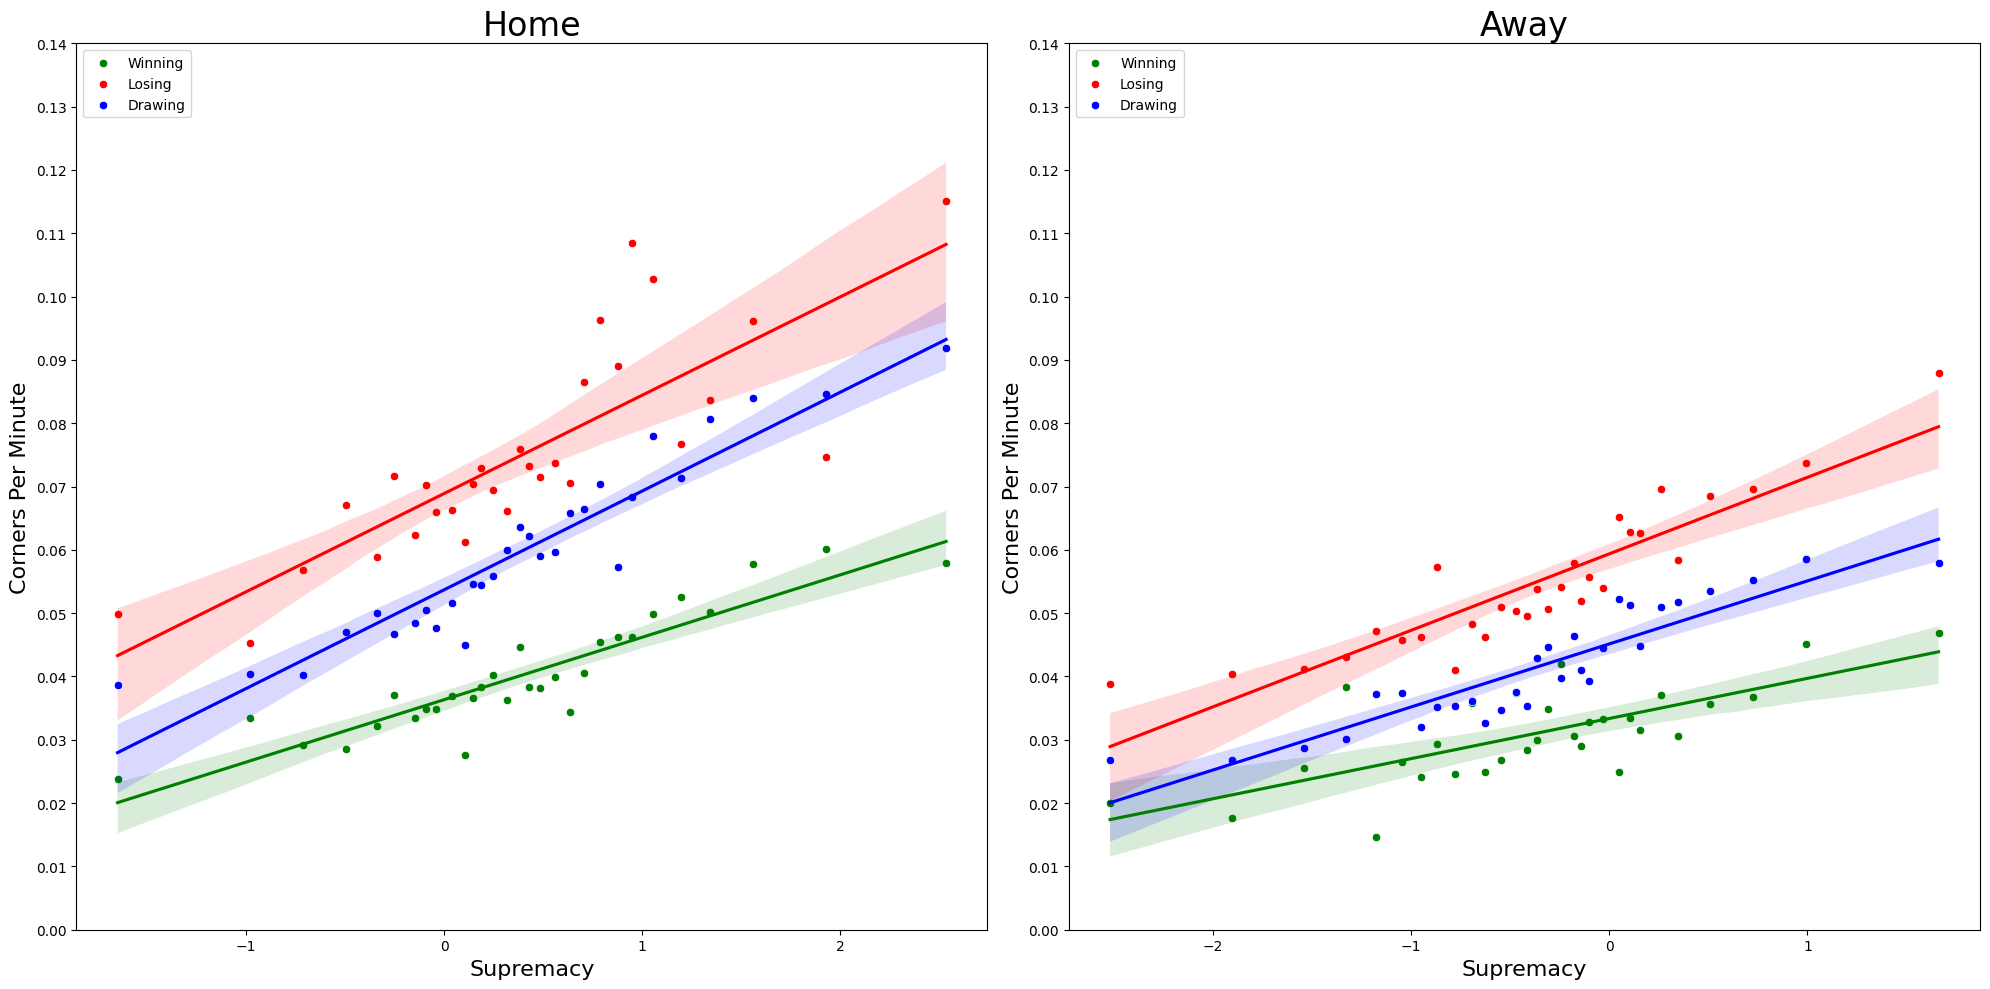

In [40]:
# Creates initial plot
fig, axes = plt.subplots(1, 2, figsize=(20, 10))  # Increase height

# Plots points for each game state with regression lines - Home
for state, color in zip(['Winning', 'Losing', 'Drawing'], ['green', 'red', 'blue']):
    df_state = df_combined_home[df_combined_home['game_state'] == state]
    sns.scatterplot(data=df_state, x='adjsup_mean', y='cpm', color=color, label=state, ax=axes[0])
    sns.regplot(data=df_state, x='adjsup_mean', y='cpm', scatter=False, color=color, ax=axes[0])

# Defines labels and titles
axes[0].set_xlabel('Supremacy', fontsize=16)
axes[0].set_ylabel('Corners Per Minute', fontsize=16)
axes[0].set_title('Home', fontsize=24)

# Customises axis ticks and labels
axes[0].tick_params(axis='both', labelsize=10)
axes[0].set_yticks(np.arange(0, 0.14, 0.01))
axes[0].legend(loc="upper left", fontsize=10)

# Plots points for each game state with regression lines - Away
for state, color in zip(['Winning', 'Losing', 'Drawing'], ['green', 'red', 'blue']):
    df_state = df_combined_away[df_combined_away['game_state'] == state]
    sns.scatterplot(data=df_state, x='adjsup_mean', y='cpm', color=color, label=state, ax=axes[1])
    sns.regplot(data=df_state, x='adjsup_mean', y='cpm', scatter=False, color=color, ax=axes[1])

# Defines labels and titles
axes[1].set_xlabel('Supremacy', fontsize=16)
axes[1].set_ylabel('Corners Per Minute', fontsize=16)
axes[1].set_title('Away', fontsize=24)

# Customises axis ticks and labels
axes[1].tick_params(axis='both', labelsize=10)
axes[1].set_yticks(np.arange(0, 0.14, 0.01)) 
axes[1].legend(loc="upper left", fontsize=10) 

plt.tight_layout()  
plt.show()

Each dot represents a bucket of minutes played at each game state and supremacy level. The lines represent the relationship between corner rates and supremacy at different game states for home and away teams. We can use these to make adjustments to raw corner statistics later in the analysis.

#### EXTRACTING COEFFICIENTS ####

In this section we use extract coefficients from the previous charts to be used in corner value adjustments

In [41]:
# Function to extract coefficients for corner value adjustments
def extract_coefficients(df, game_state):

    df_state = df[df['game_state'] == game_state]

    X = df_state[['adjsup_mean']]
    y = df_state['cpm']
    model = LinearRegression()
    model.fit(X, y)

    coefficient = model.coef_[0]
    intercept = model.intercept_

    return coefficient, intercept

# Extract coefficients for each game state - home
home_win_coeffs = extract_coefficients(df_combined_home, 'Winning')
home_lose_coeffs = extract_coefficients(df_combined_home, 'Losing')
home_draw_coeffs = extract_coefficients(df_combined_home, 'Drawing')

# Extract coefficients for each game state - away
away_win_coeffs = extract_coefficients(df_combined_away, 'Winning')
away_lose_coeffs = extract_coefficients(df_combined_away, 'Losing')
away_draw_coeffs = extract_coefficients(df_combined_away, 'Drawing')

#### CREATING ADJUSTED CORNER VALUES ####
This section creates a series of functions that uses the coefficients derived above to adjust the value of each corner based on the game state and supremacy at the point at which the corner was won. It also gives corners that are repeaters a value of 0.

In [42]:
# Average corner rates
home_avg_corner_rate = df_combined_home['corners'].sum() / df_combined_home['mins'].sum()
away_avg_corner_rate = df_combined_away['corners'].sum() / df_combined_away['mins'].sum()

# Function that adds average corner rate columns based on home or away status
def avg_corners(df):
    if df['Repeater'] == 1:
        return 0
    if  df['Home'] == df['Team'] and df['Corner'] == 1:
        return home_avg_corner_rate
    if df['Away'] == df['Team'] and df['Corner'] == 1:
        return away_avg_corner_rate
    return 0

df_gs_laliga['avg_corner_rate'] = df_gs_laliga.apply(avg_corners, axis=1)

# Function that returns the average corner rates for each corner based on game state, home status and match supremacy
def gs_sup_corners(df):
    if df['Repeater'] == 1:
        return 0
    if df['Home'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 1:
        coefficients = home_win_coeffs
    elif df['Home'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 2:
        coefficients = home_lose_coeffs
    elif df['Home'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 0:
        coefficients = home_draw_coeffs

    elif df['Away'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 2:
        coefficients = away_win_coeffs
    elif df['Away'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 1:
        coefficients = away_lose_coeffs
    elif df['Away'] == df['Team'] and df['Corner'] == 1 and df['gamestate'] == 0:
        coefficients = away_draw_coeffs
    else:
        return 0  
    
    slope = coefficients[0]
    intercept = coefficients[1]
    
    return intercept + (df['teamsup'] * slope)

df_gs_laliga['gs_sup_corner_rate'] = df_gs_laliga.apply(gs_sup_corners, axis=1)

# Function to create adjusted corner values based on these values
def adj_corner_value(df):
    if df['Corner'] == 1 and df['Repeater'] == 0:
        return  df['avg_corner_rate'] / df['gs_sup_corner_rate']
    return 0

df_gs_laliga['adj_corner_value'] = df_gs_laliga.apply(adj_corner_value, axis=1)

#### CASE STUDY ####
This section extracts all the corners from a specific match to illustrate the effect of the corner adjustments

In [43]:
# Filters for specific match and columns
df_gs_laliga_sample = df_gs_laliga[df_gs_laliga['matchid'] == '2024-08-27-Rayo Vallecano-Barcelona']
df_gs_laliga_sample = df_gs_laliga_sample[['Home', 'Away', 'Team', 'teamsup', 'gamestate', 'Corner', 'Repeater', 'Minute', 'gs_sup_corner_rate', 'avg_corner_rate', 'adj_corner_value']]
df_gs_laliga_sample = df_gs_laliga_sample[(df_gs_laliga_sample['Corner'] == 1)]
df_gs_laliga_sample[['gs_sup_corner_rate', 'avg_corner_rate', 'adj_corner_value']] = df_gs_laliga_sample[['gs_sup_corner_rate', 'avg_corner_rate', 'adj_corner_value']].round(3)

# Creates table for easy comparison
df_gs_laliga_sample_adj = (
    df_gs_laliga_sample
    .groupby(['Team', 'gamestate'])
    .agg(
        adj_cor_values=('adj_corner_value', 'max'),
        )
)

# Raw vs adjusted example
home_corners = df_gs_laliga_sample[df_gs_laliga_sample['Home'] == df_gs_laliga_sample['Team']]['Corner'].sum()
away_corners = df_gs_laliga_sample[df_gs_laliga_sample['Away'] == df_gs_laliga_sample['Team']]['Corner'].sum()
home_corners_adj = df_gs_laliga_sample[df_gs_laliga_sample['Home'] == df_gs_laliga_sample['Team']]['adj_corner_value'].sum()
away_corners_adj = df_gs_laliga_sample[df_gs_laliga_sample['Away'] == df_gs_laliga_sample['Team']]['adj_corner_value'].sum()

In [44]:
df_gs_laliga_sample

,Home,Away,Team,teamsup,gamestate,Corner,Repeater,Minute,gs_sup_corner_rate,avg_corner_rate,adj_corner_value
366025,Rayo Vallecano,Barcelona,Rayo Vallecano,-0.77,0,1,0,7,0.042,0.056,1.352
366027,Rayo Vallecano,Barcelona,Barcelona,0.77,1,1,0,19,0.069,0.043,0.622
366028,Rayo Vallecano,Barcelona,Rayo Vallecano,-0.77,1,1,0,26,0.029,0.056,1.961
366029,Rayo Vallecano,Barcelona,Barcelona,0.77,1,1,0,35,0.069,0.043,0.622
366032,Rayo Vallecano,Barcelona,Rayo Vallecano,-0.77,0,1,0,69,0.042,0.056,1.352
366034,Rayo Vallecano,Barcelona,Barcelona,0.77,0,1,0,80,0.053,0.043,0.809
366035,Rayo Vallecano,Barcelona,Barcelona,0.77,0,1,1,81,0.000,0.000,0.000
366037,Rayo Vallecano,Barcelona,Barcelona,0.77,2,1,0,88,0.038,0.043,1.117
366040,Rayo Vallecano,Barcelona,Barcelona,0.77,2,1,0,95,0.038,0.043,1.117
366041,Rayo Vallecano,Barcelona,Rayo Vallecano,-0.77,2,1,0,99,0.057,0.056,0.990


In this match the value of each corner has been adjusted to produce a value relative to game state, home/away status and match supremacy in which they were won. 

In [45]:
df_gs_laliga_sample_adj

adj_cor_values
Team           gamestate                
Barcelona      0                   0.809
               1                   0.622
               2                   1.117
Rayo Vallecano 0                   1.352
               1                   1.961
               2                   0.990

- In a drawing game state Barcelona corners are worth 0.809 and Rayo Vallecano corners are worth 1.352. This is a reflection of the gap in supremacy between the two teams.
- Whilst Rayo Vallecano is winning, Barcelona corners are worth 0.622 and Rayo Vallecano corners are worth 1.961, Barcelona are big favourites and could be expected to get lots of corners in this game state, so their corners are devalued, whereas Rayo's should be comparatively rare so their value goes up.
- Whilst Barcelona is winning, Barcelona corners are worth 1.117 and Rayo Vallecano corners are worth 0.990, here the game state and supremacy effects have almost cancelled each other out with both teams' corners being worth close to 1.
- Corners that are repeaters are given a value of 0, these are not statistically independent from the corners that preceded them so we remove them from the totals completely.

In [46]:
print(f"raw corner score: {home_corners} - {away_corners}")
print(f"adjusted corner score: {home_corners_adj} - {away_corners_adj}")

raw corner score: 6 - 6
adjusted corner score: 5.655 - 4.287


The final adjusted corner score for this match is 5.655 - 4.287, compared to the raw score of 6 - 6. These values are a more complete reflection of each teams corner performance in the match that takes into account game state, supremacy and repeaters. 

The key benefits of this approach are:
- Some of the noise in corner generation due to game state and supremacy effects has been reduced. This allows us to take averages over a smaller sample size when generating a team’s corner attack and defence ratings to feed into a predictive model. Taking a smaller sample size of matches is advantageous because it means we can pick up on changes in manager, personnel and playing style faster.
- As we are revaluing corner performance in the context of opponent strength, the composition of opponents in the sample matters less. Again, this allows us to be more flexible with the size and composition of the sample of opponents faced when assessing a team's corner performances.
- A predictive model that uses these adjusted ratings will need to have match supremacy as a feature to ensure it accounts for the relative strengths of the two teams, given some of this effect has been stripped out of the ratings. By anchoring the predictions to pre match betting lines (which are assumed to be efficient) predictions will take into account the current overall strength of each team whilst using ratings that accounted for their historical corner strength with supremacy factors stripped out.
- Another advantage of accounting for supremacy in this way is that promoted or relegated teams can easily be incorporated into this system. Their ratings from their previous league will be valid in the context of the new league as the difference in quality will already be baked into their ratings from the previous league and the match supremacy of upcoming fixtures.

### LIMITATIONS AND FURTHER IMPROVEMENTS ###

- This analysis provides a theoretical framework for developing optimised team corner attack and defence ratings to be used in predictive models, the exact methodology and application of how these ratings are used in a predictive model are not specified here.
- More work is needed to test these adjusted ratings against non-adjusted ratings, both in terms of statistical efficiency and their ability to beat historic betting lines. Both of these areas have been explored but not included here as they go beyond the scope of the project.
- Other in game factors that affect corner generation in the short term could be taken into account. For example, playing against a team that has had a player sent off, or looking at the timing as well as game state of each corner within each match (game state effects are bigger as the match progresses).
- Out of game factors such as manager changes, player transfers, differing levels of motivation at the end of season are not factored in. In cases where these are quantifiable by looking at historical trends we could include these in our ratings.
- With player level data the effect of individual players propensity to create or prevent corner creating actions could be factored in. This could help refine our predictions in the context of line up changes, injuries and suspensions.
- Due to limitations in the data set used for this analysis we do not know the exact length of each match or each half, we have had to rely on assumptions and estimates based on event data and historical averages. A better source data set with more granular information could allow us to make more refined calculations and help optimise the ratings.
- Further refinement of the ratings could include optimising and weighting the time frames in which they are aggregated, the weightings given to home and away form, incorporating data from matches played by the teams in cup competitions and incorporating adjustments for promoted and relegated teams that go beyond match supremacies.